# Part 1: Data Analysis

The goal of this notebook is to practice the techniques introduced in **Part 1: Data Analysis** of *Advances in Financial Machine Learning* by Marcos López de Prado. Through Python implementations and experiments with financial data, I aim to understand how these methods prepare data for financial machine learning.

The notebook is organized into four sections:

1. **Financial Data Structures** — Explore how financial observations are organized, sampled, and transformed into useful datasets.
2. **Labeling** — Practice assigning targets to financial observations, including the triple-barrier method and meta-labeling.
3. **Sample Weights** — Explore how overlapping observations, sample uniqueness, and time decay affect the weight assigned to each training example.
4. **Fractionally Differentiated Features** — Practice fractional differentiation to balance stationarity with the preservation of information from past observations.

Each section will combine explanations, code, and observations from the results to build a practical understanding of the techniques.


## Study Signal: Wilder's 14-Period RSI

We will use **Wilder's 14-period Relative Strength Index (RSI)** to define entry signals, first for **MSFT**, then for each stock in the small-, medium-, and large-cap baskets. A period is one price bar: 14 hourly bars with `interval="1H"` or 14 daily bars with `interval="1D"`.

### RSI calculation

For closing price $P_t$, define the price change, gain, and nonnegative loss:

$$
\Delta P_t=P_t-P_{t-1},\qquad
G_t=\max(\Delta P_t,0),\qquad
L_t=\max(-\Delta P_t,0).
$$

Initialize the averages with the first 14 price changes (requiring 15 closing prices):

$$
\overline{G}_{14}=\frac{1}{14}\sum_{i=1}^{14}G_i,
\qquad
\overline{L}_{14}=\frac{1}{14}\sum_{i=1}^{14}L_i.
$$

For subsequent bars, apply Wilder's recursive smoothing:

$$
\overline{G}_t=\frac{13\overline{G}_{t-1}+G_t}{14},
\qquad
\overline{L}_t=\frac{13\overline{L}_{t-1}+L_t}{14}.
$$

Relative strength and RSI are then:

$$
RS_t=\frac{\overline{G}_t}{\overline{L}_t},
\qquad
RSI_t=100-\frac{100}{1+RS_t}.
$$

If average loss is zero and average gain is positive, RSI is 100; if average gain is zero and average loss is positive, RSI is 0. For this study, we will assign RSI = 50 when both averages are zero. RSI remains unavailable until the initial 14 price changes exist.

### Entry rules

We interpret crossing oversold as entering below 30, and crossing overbought as entering above 70:

$$
s_t=
\begin{cases}
+1 & \text{if } RSI_{t-1}\geq30\text{ and }RSI_t<30\quad\text{(long entry)},\\
-1 & \text{if } RSI_{t-1}\leq70\text{ and }RSI_t>70\quad\text{(short entry)},\\
0 & \text{otherwise (no new entry)}.
\end{cases}
$$

The signal is an entry event rather than a continuously held position. Staying beyond a threshold does not generate another entry. Evaluate crossings only when both RSI values are available, and act after bar $t$ closes. Holding periods and exits will be specified in the labeling study.

**Reference:** [RSI calculation and Wilder smoothing — StockCharts ChartSchool](https://chartschool.stockcharts.com/table-of-contents/technical-indicators-and-overlays/technical-indicators/relative-strength-index-rsi).


Loaded 3,466 hourly bars
Available range: 2024-10-04 14:30:00-04:00 to 2026-10-02 15:30:00-04:00


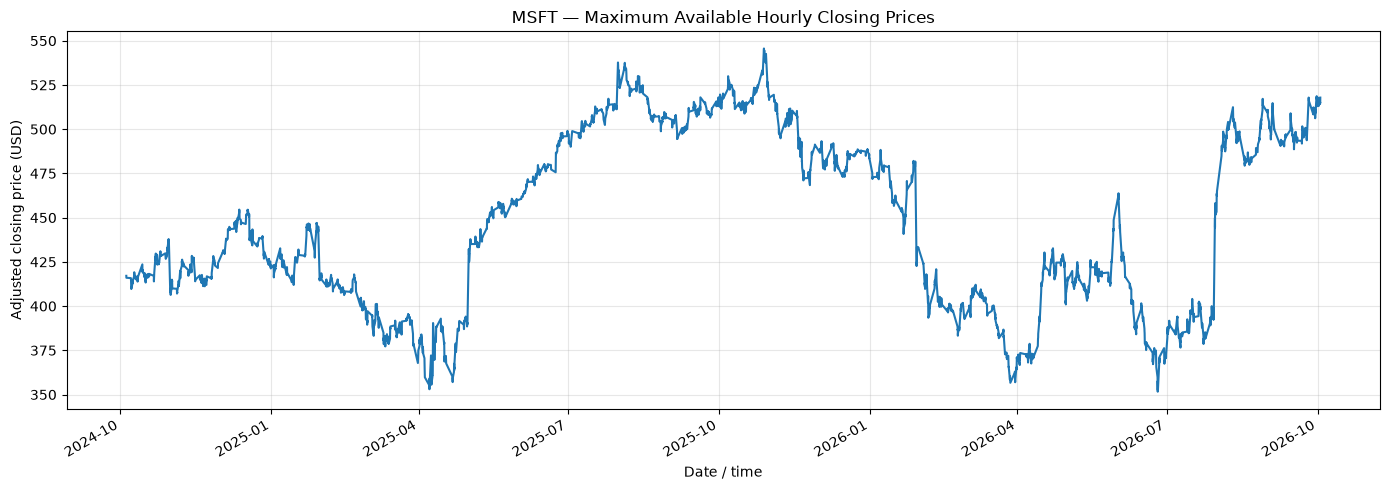

In [6]:
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd

# Request the maximum hourly history Yahoo Finance makes available.
# Hourly history is limited to roughly the most recent 730 days.
msft_hourly = yf.Ticker("MSFT").history(
    period="max",
    interval="1h",
    auto_adjust=True,
)
if msft_hourly.empty:
    raise ValueError("Yahoo Finance returned no hourly MSFT data.")

msft_hourly = msft_hourly.sort_index()
msft_prices = msft_hourly[["Close"]].rename(columns={"Close": "MSFT"})
print(f"Loaded {len(msft_prices):,} hourly bars")
print(f"Available range: {msft_prices.index.min()} to {msft_prices.index.max()}")

ax = msft_prices.plot(
    figsize=(14, 5),
    legend=False,
    title="MSFT — Maximum Available Hourly Closing Prices",
)
ax.set_xlabel("Date / time")
ax.set_ylabel("Adjusted closing price (USD)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


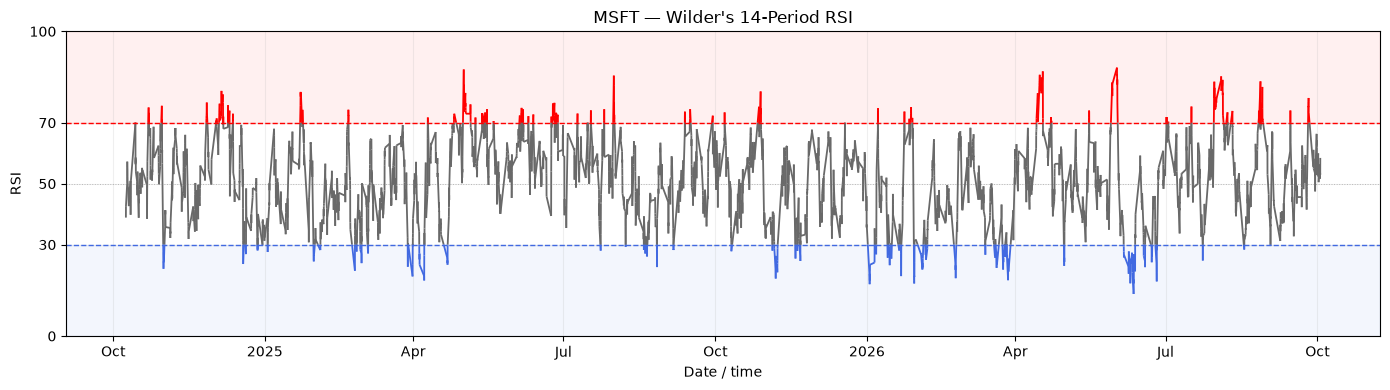

Total signals: 141
Sell signals (short entries): 76
Buy signals (long entries): 65


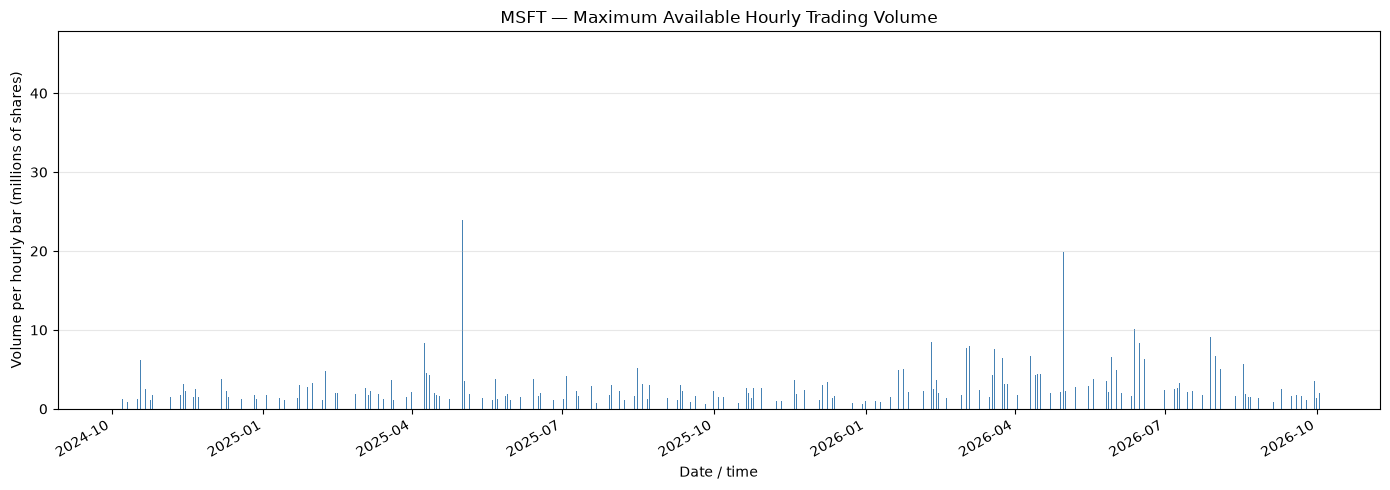

In [7]:
from pathlib import Path
import sys

# Add the project root before importing the HelperFunctions package.
project_root = next(
    (folder for folder in (Path.cwd(), *Path.cwd().parents)
     if (folder / "HelperFunctions" / "signals.py").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        "Cannot locate HelperFunctions/signals.py. Start the notebook kernel "
        "from the QuantitativeMethods project folder or one of its subfolders."
    )
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from HelperFunctions.signals import wilder_rsi

# Accepts one or many ticker columns; plotting is optional.
msft_rsi = wilder_rsi(msft_prices, periods=14, plot=True)

# Count threshold crossings only, rather than every bar beyond a threshold.
previous_rsi = msft_rsi.shift(1)
valid_rsi = msft_rsi.notna() & previous_rsi.notna()
buy_signals = valid_rsi & (previous_rsi >= 30) & (msft_rsi < 30)
sell_signals = valid_rsi & (previous_rsi <= 70) & (msft_rsi > 70)

buy_count = int(buy_signals.to_numpy().sum())
sell_count = int(sell_signals.to_numpy().sum())
total_signals = buy_count + sell_count
print(f"Total signals: {total_signals:,}")
print(f"Sell signals (short entries): {sell_count:,}")
print(f"Buy signals (long entries): {buy_count:,}")

from HelperFunctions.data import get_stock_volume

msft_volume = get_stock_volume("MSFT", period="max", interval="1H")

# Plot shares traded in each hourly bar, displayed in millions.
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(
    msft_volume.index,
    msft_volume["MSFT"] / 1_000_000,
    width=pd.Timedelta(minutes=45),
    color="steelblue",
    linewidth=0,
)
ax.set_title("MSFT — Maximum Available Hourly Trading Volume")
ax.set_xlabel("Date / time")
ax.set_ylabel("Volume per hourly bar (millions of shares)")
ax.grid(True, axis="y", alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## Triple-Barrier Meta-Labels

**Reference:** Marcos López de Prado (2018), *Advances in Financial Machine Learning*, Part 1, Chapter 3, **Labeling**: §3.3 **Computing Dynamic Thresholds**, §3.4 **The Triple-Barrier Method**, and §§3.6–3.7 **Meta-Labeling** and **How to Use Meta-Labeling**. Relevant implementation examples are Snippet 3.1 (volatility), Snippet 3.4 (vertical barriers), and Snippets 3.6–3.7 (events and binary meta-labels).

Our study adapts the framework to consecutive-bar volatility and close-only monitoring. Every RSI crossing is an independent event, including overlapping trades. The RSI rule supplies the side $s_i\in\{+1,-1\}$; the labeling algorithm determines the historical outcome. It does not train a model.

### Volatility target

For closing price $P_t$, consecutive-bar simple returns are:

$$
r_t=\frac{P_t}{P_{t-1}}-1,
\qquad
\alpha=\frac{2}{S+1},
$$

where $S$ is the configurable EWMA span in bars. For the valid returns available through $t$, normalized exponential weights and their weighted mean are:

$$
w_{t,k}=\frac{(1-\alpha)^{t-k}}{\sum_{j=1}^{t}(1-\alpha)^{t-j}},
\qquad
\mu_t=\sum_{k=1}^{t}w_{t,k}r_k.
$$

The bias-corrected weighted standard deviation used by `ewm(adjust=True).std(bias=False)` is:

$$
\sigma_t=
\sqrt{\frac{\sum_{k=1}^{t}w_{t,k}(r_k-\mu_t)^2}
{1-\sum_{k=1}^{t}w_{t,k}^2}}.
$$

The volatility frequency follows the data, with no annualization: hourly bars produce hourly-return volatility. For event $i$, freeze $\sigma_i=\sigma_{t_i}$ at its signal-close entry time $t_i$. Warm-up and minimum-target filters can exclude events with unavailable or insufficient volatility.

### Horizontal and vertical barriers

Enter at $P_{t_i}$ and monitor only subsequent closing prices. The side-adjusted return is:

$$
R_i(t)=s_i\left(\frac{P_t}{P_{t_i}}-1\right),\qquad t>t_i.
$$

With independent positive multipliers $m_{\mathrm{PT}}$ and $m_{\mathrm{SL}}$, the first horizontal touches are:

$$
\tau_i^{\mathrm{PT}}=\inf\{t>t_i:R_i(t)\geq m_{\mathrm{PT}}\sigma_i\},
$$

$$
\tau_i^{\mathrm{SL}}=\inf\{t>t_i:R_i(t)\leq -m_{\mathrm{SL}}\sigma_i\}.
$$

Equivalently, their price levels are:

$$
P_i^{\mathrm{PT}}=P_{t_i}(1+s_i m_{\mathrm{PT}}\sigma_i),
\qquad
P_i^{\mathrm{SL}}=P_{t_i}(1-s_i m_{\mathrm{SL}}\sigma_i).
$$

For a configurable holding limit of $D$ calendar days, use the first observed close at or after the elapsed-time deadline:

$$
\tau_i^{\mathrm{V}}=\inf\{t\in\mathcal{T}:t\geq t_i+D\text{ days}\},
\qquad
t_{1,i}=\min(\tau_i^{\mathrm{PT}},\tau_i^{\mathrm{SL}},\tau_i^{\mathrm{V}}),
$$

where $\mathcal{T}$ contains the observed bar timestamps. An untouched or unavailable barrier has no finite touch time. A horizontal touch on the vertical-exit close takes precedence when recording the exit reason. Exits use the observed closing price, which may overshoot the theoretical barrier.

### Binary meta-labels

For a completed event, realized return and label are:

$$
\mathrm{ret}_i=s_i\left(\frac{P_{t_{1,i}}}{P_{t_i}}-1\right),
\qquad
y_i=\mathbf{1}\{\mathrm{ret}_i>0\}.
$$

Profit-taking exits receive **1**; stop-loss exits receive **0**. Time exits receive **1** when profitable and **0** when losing or flat. Returns ignore trading costs. If the dataset ends before the vertical exit and no horizontal barrier was touched, the event remains **incomplete** and receives no label. Preserve all event IDs and entry/exit timestamps for the subsequent overlap analysis.


In [11]:
import pandas as pd
from HelperFunctions.labeling import estimate_volatility, create_events, get_labels

# Adjustable study parameters. Span and warm-up are measured in data bars.
volatility_span = 100
volatility_min_periods = 2
profit_taking_multiplier = 3.0
stop_loss_multiplier = 1.0
max_holding_days = 7
min_target_return = 0.0

# All crossings are independent entries, including overlapping trades.
trade_sides = buy_signals.astype(int) - sell_signals.astype(int)
msft_volatility = estimate_volatility(
    msft_prices, span=volatility_span, min_periods=volatility_min_periods
)
msft_events = create_events(
    msft_prices,
    trade_sides,
    volatility=msft_volatility,
    pt_mult=profit_taking_multiplier,
    sl_mult=stop_loss_multiplier,
    holding_days=max_holding_days,
    min_ret=min_target_return,
)
msft_labels = get_labels(msft_events)

print(f"Total signal events: {len(msft_events):,}")
print("Event status counts:")
print(msft_events["status"].value_counts().to_string())
print("\nCompleted exit counts:")
print(msft_labels["exit_type"].value_counts().to_string())
print(f"\nProfitable labels (1): {int(msft_labels['bin'].eq(1).sum()):,}")
print(f"Unprofitable/flat labels (0): {int(msft_labels['bin'].eq(0).sum()):,}")
display(msft_events.head())
display(msft_labels.head())


Total signal events: 141
Event status counts:
status
complete    141

Completed exit counts:
exit_type
stop_loss        99
profit_taking    34
time              8

Profitable labels (1): 41
Unprofitable/flat labels (0): 100


,ticker,signal_time,entry_time,entry_price,side,trgt,pt_mult,sl_mult,pt_return,sl_return,...,sl_price,deadline,vertical_time,status,exclusion_reason,pt_time,sl_time,t1,exit_type,exit_price
event_id,,,,,,,,,,,,,,,,,,,,,
0,MSFT,2024-10-14 09:30:00-04:00,2024-10-14 09:30:00-04:00,423.595001,-1,0.004337,3.0,1.0,0.013012,-0.004337,...,425.432292,2024-10-21 09:30:00-04:00,2024-10-21 09:30:00-04:00,complete,None,2024-10-15 10:30:00-04:00,NaT,2024-10-15 10:30:00-04:00,profit_taking,416.690002
1,MSFT,2024-10-22 09:30:00-04:00,2024-10-22 09:30:00-04:00,428.070007,-1,0.005030,3.0,1.0,0.015091,-0.005030,...,430.223364,2024-10-29 09:30:00-04:00,2024-10-29 09:30:00-04:00,complete,None,NaT,2024-10-25 09:30:00-04:00,2024-10-25 09:30:00-04:00,stop_loss,431.000092
2,MSFT,2024-10-22 12:30:00-04:00,2024-10-22 12:30:00-04:00,427.350006,-1,0.004928,3.0,1.0,0.014784,-0.004928,...,429.455945,2024-10-29 12:30:00-04:00,2024-10-29 12:30:00-04:00,complete,None,NaT,2024-10-22 13:30:00-04:00,2024-10-22 13:30:00-04:00,stop_loss,429.695007
3,MSFT,2024-10-30 09:30:00-04:00,2024-10-30 09:30:00-04:00,437.869995,-1,0.004472,3.0,1.0,0.013416,-0.004472,...,439.828148,2024-11-06 08:30:00-05:00,2024-11-06 09:30:00-05:00,complete,None,2024-10-31 09:30:00-04:00,NaT,2024-10-31 09:30:00-04:00,profit_taking,407.739990
4,MSFT,2024-10-30 12:30:00-04:00,2024-10-30 12:30:00-04:00,437.424988,-1,0.004368,3.0,1.0,0.013103,-0.004368,...,439.335483,2024-11-06 11:30:00-05:00,2024-11-06 11:30:00-05:00,complete,None,2024-10-31 09:30:00-04:00,NaT,2024-10-31 09:30:00-04:00,profit_taking,407.739990


,ticker,entry_time,t1,side,exit_type,raw_return,ret,bin
event_id,,,,,,,,
0,MSFT,2024-10-14 09:30:00-04:00,2024-10-15 10:30:00-04:00,-1,profit_taking,-0.016301,0.016301,1
1,MSFT,2024-10-22 09:30:00-04:00,2024-10-25 09:30:00-04:00,-1,stop_loss,0.006845,-0.006845,0
2,MSFT,2024-10-22 12:30:00-04:00,2024-10-22 13:30:00-04:00,-1,stop_loss,0.005487,-0.005487,0
3,MSFT,2024-10-30 09:30:00-04:00,2024-10-31 09:30:00-04:00,-1,profit_taking,-0.068810,0.068810,1
4,MSFT,2024-10-30 12:30:00-04:00,2024-10-31 09:30:00-04:00,-1,profit_taking,-0.067863,0.067863,1


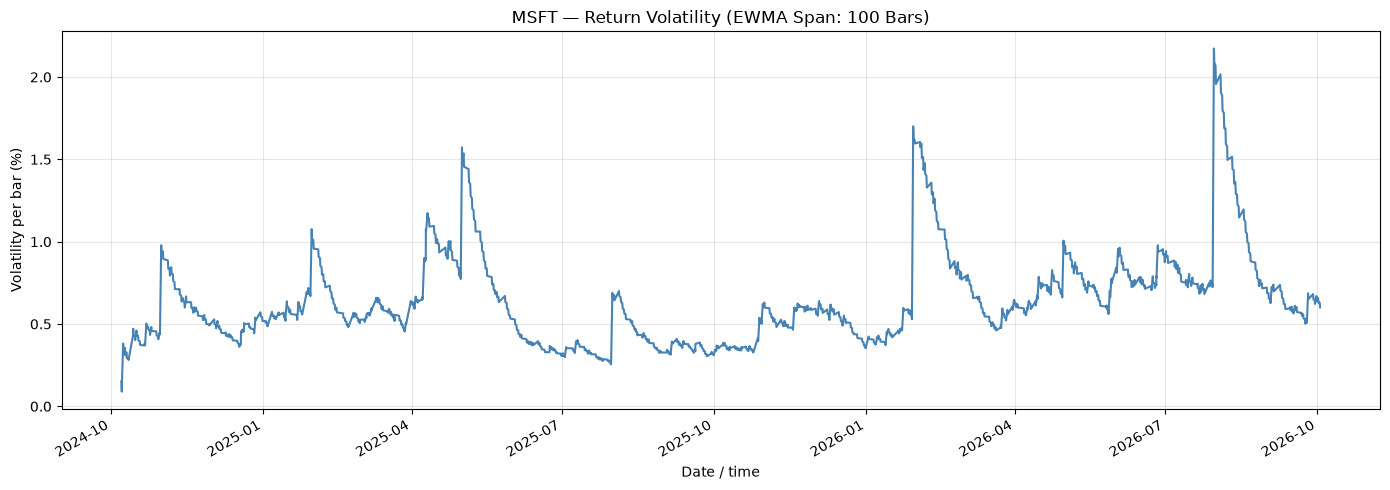

In [9]:
# Volatility is the standard deviation of returns at the input bar frequency.
ax = (msft_volatility * 100).plot(
    figsize=(14, 5),
    legend=False,
    color="steelblue",
    title=f"MSFT — Return Volatility (EWMA Span: {volatility_span} Bars)",
)
ax.set_xlabel("Date / time")
ax.set_ylabel("Volatility per bar (%)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


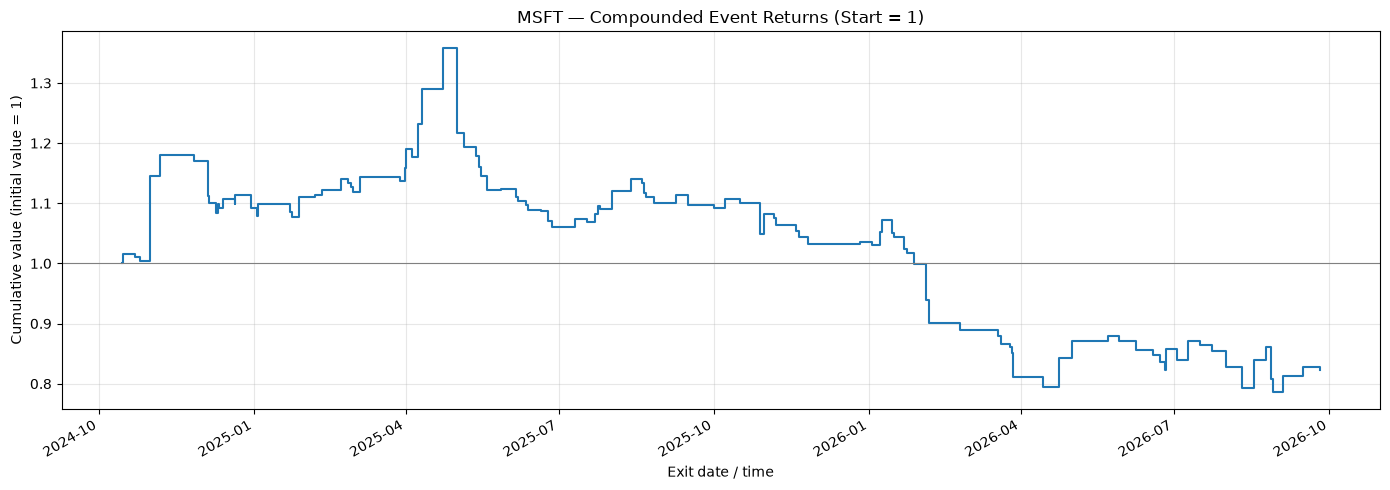

In [12]:
from HelperFunctions.signals import plot_cumulative_returns

# Start at 1 and multiply by (1 + trade return) in exit-time order.
# Overlapping events are retained; this is an event-return summary.
msft_cumulative_returns = plot_cumulative_returns(msft_events, max_workers=32)
